In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('ushape.csv')

In [29]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [30]:
df.rename(columns={'3.159499363321345566e-02' : 'X', '9.869877579082642072e-01' : 'Y', '0.000000000000000000e+00' : 'class'}, inplace=True)

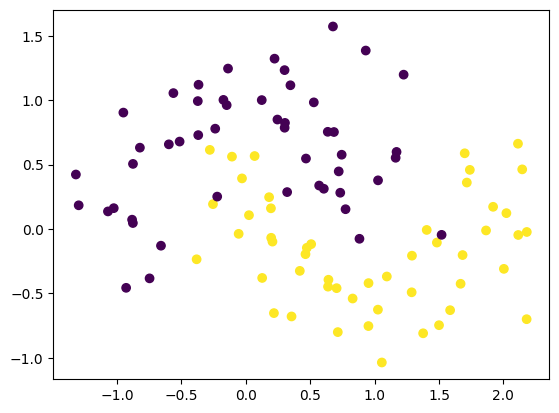

In [31]:
plt.scatter(x = df['X'], y=df['Y'], c=df['class'])

In [32]:
X = df.iloc[:, 0:2].values
Y = df.iloc[:,-1].values

In [33]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [34]:
# model = Sequential()

# model.add(Dense(10, activation='relu', input_dim=2, kernel_initializer='glorot_uniform'))
# model.add(Dense(10, activation='relu' ,kernel_initializer='glorot_uniform'))
# model.add(Dense(10, activation='relu', kernel_initializer='glorot_uniform'))
# model.add(Dense(10, activation='relu', kernel_initializer='glorot_uniform'))
# model.add(Dense(1, activation='sigmoid'))

In [35]:
model = Sequential()

model.add(Dense(10, activation='tanh', input_dim=2))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\ABDULLAH AL MASUM\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.get_weights()

[array([[-0.2819995 ,  0.37063545,  0.48302156, -0.68319684,  0.70642096,
         -0.5697136 ,  0.68957704, -0.36857218, -0.49160472,  0.0823158 ],
        [ 0.26536733,  0.00305951, -0.17700529,  0.41570038, -0.61520183,
         -0.04313898,  0.26326656,  0.1623618 , -0.15767509, -0.16429818]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.16076842, -0.44496465,  0.246378  , -0.12744269,  0.21569198,
         -0.4513599 , -0.07170063, -0.514169  , -0.2224662 , -0.01973069],
        [-0.266285  ,  0.2861908 , -0.4033175 , -0.32747245, -0.25224715,
         -0.3850494 ,  0.16169077,  0.20366448,  0.03393024,  0.02187377],
        [-0.1304129 , -0.46364725,  0.21083951,  0.03971159, -0.30850816,
         -0.49950963, -0.3637928 , -0.545576  ,  0.27228665, -0.30610028],
        [ 0.14575297,  0.52473176, -0.3977208 ,  0.23982114,  0.48522377,
          0.32121068,  0.06739306, -0.30069593,  0.3727724 ,  0.0692336 ],
        [-0.28725

In [38]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [39]:
history = model.fit(X, Y, epochs=100, validation_split=.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.3544 - loss: 0.7306 - val_accuracy: 0.2500 - val_loss: 0.7491
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3924 - loss: 0.7143 - val_accuracy: 0.3500 - val_loss: 0.7262
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5063 - loss: 0.6984 - val_accuracy: 0.4500 - val_loss: 0.7045
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5823 - loss: 0.6845 - val_accuracy: 0.6500 - val_loss: 0.6834
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6835 - loss: 0.6709 - val_accuracy: 0.8000 - val_loss: 0.6631
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8101 - loss: 0.6566 - val_accuracy: 0.8500 - val_loss: 0.6439
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7975 - loss: 0.6436 - val_accuracy: 0.8500 - val_loss: 0.6251
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7975 - loss: 0.6311 - val_accuracy: 0.8500 - val_loss

In [40]:
model.predict(np.array([[0.882490,	-0.075756]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


array([[0.8542407]], dtype=float32)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

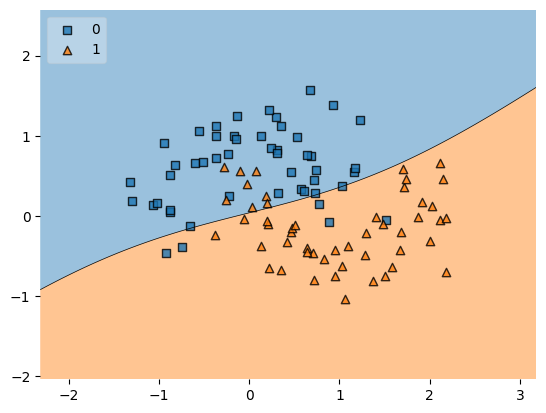

In [41]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, Y.astype('int'), clf=model, legend=2)

# Uniform Distribution

In [64]:
model2 = Sequential()

model2.add(Dense(10, activation='tanh', input_dim=2, kernel_initializer='glorot_uniform'))
model2.add(Dense(10, activation='tanh' ,kernel_initializer='glorot_uniform'))
model2.add(Dense(10, activation='tanh', kernel_initializer='glorot_uniform'))
model2.add(Dense(10, activation='tanh', kernel_initializer='glorot_uniform'))
model2.add(Dense(1, activation='sigmoid'))

In [65]:
model2.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model2.get_weights()

[array([[-0.34401268, -0.6256125 ,  0.34327596,  0.42138177, -0.2033208 ,
          0.19466972, -0.00968736,  0.02910811,  0.35680646, -0.10733455],
        [-0.02913576,  0.53022116, -0.08750391, -0.35801068, -0.01106793,
         -0.6227534 ,  0.6913845 , -0.30675673,  0.53845114, -0.13946629]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.4292379 ,  0.43338102,  0.32699215, -0.18766758,  0.11456966,
          0.44056582, -0.4130301 , -0.17526191, -0.23022687,  0.41194856],
        [-0.2605461 ,  0.16080552, -0.42961502,  0.4665122 , -0.2533629 ,
          0.24348706,  0.20778114,  0.45007104, -0.19884244, -0.27920258],
        [-0.13528943, -0.10395828,  0.27970678,  0.08801359,  0.18234956,
          0.1883632 , -0.01617908,  0.1752389 ,  0.22364551, -0.5064638 ],
        [-0.10364893, -0.3888358 ,  0.13816315,  0.47497725,  0.30832368,
          0.5084058 ,  0.39498502, -0.25753435, -0.3897482 , -0.39631438],
        [ 0.21119

In [67]:
inittial_weights = model2.get_weights()

In [68]:
inittial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
inittial_weights[1] = np.zeros(model2.get_weights()[1].shape)
inittial_weights[2] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[3] = np.zeros(model2.get_weights()[3].shape)
inittial_weights[4] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[5] = np.zeros(model2.get_weights()[5].shape)
inittial_weights[6] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[7] = np.zeros(model2.get_weights()[7].shape)
inittial_weights[8] = np.random.randn(10,1)*np.sqrt(1/2)
inittial_weights[9] = np.zeros(model2.get_weights()[9].shape)

In [69]:
model2.set_weights(inittial_weights)

In [70]:
model2.get_weights()

[array([[ 0.34796563, -0.02060165,  1.4004006 ,  0.3660797 , -1.8005834 ,
         -0.99727476, -0.32093054,  0.4001614 , -2.0123336 ,  0.62716264],
        [ 0.26894698,  0.7774091 ,  0.14465642, -0.0454062 ,  0.01074639,
          0.56434923, -0.5381296 , -0.58488095,  0.86048776,  0.15638018]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 1.0924511 ,  0.9970643 , -0.15010685, -0.15206973,  0.47917408,
         -0.16679388, -0.8964658 , -2.1257885 ,  0.43609157,  0.22993515],
        [ 0.07076593,  0.07171555, -0.06509545, -0.2741738 ,  0.41953713,
          1.1857365 , -1.244748  , -0.13062061,  0.8607997 ,  0.3203011 ],
        [-0.6340949 , -0.48841196, -0.22210647, -0.7419743 , -0.12212764,
          1.1245303 , -0.49740535,  2.424109  , -0.4047739 , -0.09846718],
        [ 1.0164394 , -0.67989975,  0.14060314,  0.6744436 , -0.05096   ,
          1.422417  , -0.30741617, -0.13195814,  0.06733871, -0.08292221],
        [-0.36499

In [71]:
model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [72]:
history2 = model2.fit(X, Y, epochs=100, validation_split=.2)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.7089 - loss: 0.6076 - val_accuracy: 0.8500 - val_loss: 0.4713
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7215 - loss: 0.5923 - val_accuracy: 0.8500 - val_loss: 0.4521
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7215 - loss: 0.5793 - val_accuracy: 0.8500 - val_loss: 0.4369
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7215 - loss: 0.5670 - val_accuracy: 0.8500 - val_loss: 0.4220
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7215 - loss: 0.5558 - val_accuracy: 0.8500 - val_loss: 0.4091
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7342 - loss: 0.5455 - val_accuracy: 0.8500 - val_loss: 0.3964
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7468 - loss: 0.5353 - val_accuracy: 0.8500 - val_loss: 0.3846
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7595 - loss: 0.5264 - val_accuracy: 0.8500 - val_loss: 0.3757
Epo

In [73]:
model2.get_weights()

[array([[ 0.33094823, -0.1208235 ,  1.5303944 ,  0.4481318 , -1.703405  ,
         -1.1243273 , -0.2638809 ,  0.42542222, -1.820576  ,  0.8380343 ],
        [ 0.20517126,  0.7252453 ,  0.10169058, -0.10024147, -0.0728455 ,
          0.5217333 , -0.55709374, -0.5426471 ,  0.8676466 ,  0.1599229 ]],
       dtype=float32),
 array([ 0.06736554,  0.02651869, -0.14261457, -0.22337009, -0.16760641,
        -0.15323274,  0.05644337,  0.07409168, -0.09408376,  0.076126  ],
       dtype=float32),
 array([[ 1.0220963 ,  0.90810686, -0.04594258, -0.00422639,  0.46401304,
         -0.20066708, -0.8551099 , -2.2321765 ,  0.3846793 ,  0.30805054],
        [ 0.04365306,  0.08541824, -0.06026251, -0.30050632,  0.4278184 ,
          1.1881175 , -1.171012  , -0.09842581,  0.8364991 ,  0.29280326],
        [-0.79652405, -0.48034325, -0.20785268, -0.6702217 , -0.29161045,
          1.1854589 , -0.43116105,  2.2902422 , -0.61847466, -0.12387061],
        [ 1.1292498 , -0.86442673,  0.30317864,  0.8720895 , 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


<Axes: >

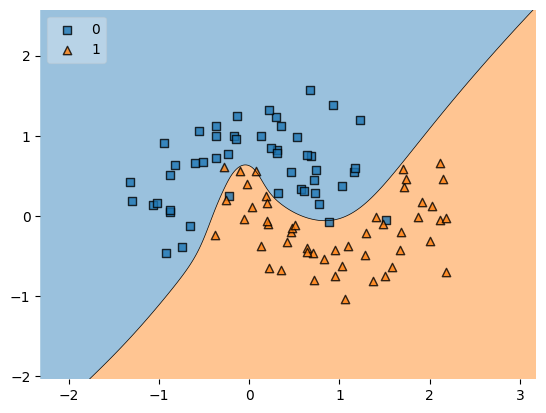

In [74]:
plot_decision_regions(X,Y.astype('int'), clf=model2, legend=2)

# Normal Distribution

In [75]:
model3 = Sequential()

model3.add(Dense(10, activation='tanh', input_dim=2, kernel_initializer='glorot_normal'))
model3.add(Dense(10, activation='tanh' ,kernel_initializer='glorot_normal'))
model3.add(Dense(10, activation='tanh', kernel_initializer='glorot_normal'))
model3.add(Dense(10, activation='tanh', kernel_initializer='glorot_normal'))
model3.add(Dense(1, activation='sigmoid'))

In [76]:
model3.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
model3.get_weights()

[array([[ 0.10484119, -0.6060255 , -0.7658257 ,  0.00606824,  0.01327817,
          0.04535011, -0.4741871 , -0.04358681, -0.4451686 ,  0.5178594 ],
        [ 0.23164739,  0.18398912,  0.2962604 ,  0.08805558, -0.5247653 ,
         -0.9235215 , -0.27750012, -0.01889431,  0.17079066,  0.11111225]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.23766884,  0.55023247, -0.30717936, -0.18725298, -0.09053475,
          0.33652204,  0.5411602 ,  0.14113803,  0.5416311 , -0.18407632],
        [-0.04504041, -0.3931206 , -0.27326307,  0.581338  ,  0.28638315,
          0.47203282,  0.10771081, -0.467999  ,  0.43377963, -0.6972277 ],
        [ 0.23200555,  0.28237078,  0.20076667,  0.3587086 ,  0.10335428,
         -0.25261667,  0.07780445, -0.11408293, -0.32732362, -0.09938623],
        [-0.24001853, -0.10960631, -0.6161988 ,  0.10169812, -0.2775871 ,
         -0.00379947,  0.6718912 ,  0.5220491 , -0.53971195,  0.0180862 ],
        [ 0.27494

In [78]:
inittial_weights = model3.get_weights()

In [79]:
inittial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
inittial_weights[1] = np.zeros(model3.get_weights()[1].shape)
inittial_weights[2] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[3] = np.zeros(model3.get_weights()[3].shape)
inittial_weights[4] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[5] = np.zeros(model3.get_weights()[5].shape)
inittial_weights[6] = np.random.randn(10,10)*np.sqrt(1/2)
inittial_weights[7] = np.zeros(model3.get_weights()[7].shape)
inittial_weights[8] = np.random.randn(10,1)*np.sqrt(1/2)
inittial_weights[9] = np.zeros(model3.get_weights()[9].shape)

In [80]:
model3.set_weights(inittial_weights)

In [81]:
model3.get_weights()

[array([[-1.0974481 ,  0.51134866,  0.1450464 ,  0.16827366,  0.86487937,
          0.2541634 ,  0.8471593 , -2.2471025 ,  0.6231332 , -0.20400019],
        [-0.00858048,  0.11683971,  0.9590812 ,  0.86392915,  0.73888624,
          1.3057469 ,  0.04296965, -0.8386593 ,  0.7167457 , -0.3115704 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.11396005,  0.9024101 , -0.60167867, -1.0929334 , -0.2928774 ,
          0.88728446,  1.1456474 , -0.340496  , -0.42634746,  0.80421734],
        [-0.17631905,  0.37699547, -0.5702844 , -1.5177717 , -0.5315871 ,
          0.49470606,  0.05799272,  0.21462032, -0.49670082,  0.9062419 ],
        [-0.4303885 , -0.8877252 ,  0.5182149 , -1.4982276 ,  0.2057583 ,
         -0.23484384,  0.29682752, -0.1085724 , -0.32062796, -0.9600649 ],
        [-0.31104642,  0.7208622 ,  0.67669696, -0.29462022, -0.46574545,
         -0.07514443, -0.44808063, -0.04783313, -0.3660327 , -0.6366843 ],
        [ 0.26114

In [82]:
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [83]:
history2 = model3.fit(X, Y, epochs=100, validation_split=.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step - accuracy: 0.5190 - loss: 0.8214 - val_accuracy: 0.3500 - val_loss: 1.0046
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5443 - loss: 0.7850 - val_accuracy: 0.3500 - val_loss: 0.9551
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5823 - loss: 0.7472 - val_accuracy: 0.3500 - val_loss: 0.9067
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5949 - loss: 0.7148 - val_accuracy: 0.4000 - val_loss: 0.8579
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5949 - loss: 0.6850 - val_accuracy: 0.4000 - val_loss: 0.8103
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5949 - loss: 0.6618 - val_accuracy: 0.4500 - val_loss: 0.7633
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6203 - loss: 0.6385 - val_accuracy: 0.5000 - val_loss: 0.7198
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6329 - loss: 0.6165 - val_accuracy: 0.5500 - val_loss

In [84]:
model3.get_weights()

[array([[-0.9072745 ,  0.5100895 ,  0.21455608,  0.05368255,  0.8817162 ,
          0.16308703,  0.7889036 , -2.242795  ,  0.59959996, -0.06310116],
        [ 0.12664936,  0.2626126 ,  0.88773996,  0.8699729 ,  0.8001687 ,
          1.438441  ,  0.01398127, -0.7740313 ,  0.792211  , -0.39902115]],
       dtype=float32),
 array([ 0.05873443,  0.06091528, -0.11869737, -0.10498822,  0.08765763,
         0.08908458, -0.08892462,  0.17228301,  0.03899274,  0.00533714],
       dtype=float32),
 array([[-0.1780517 ,  0.8828111 , -0.49627575, -0.99065393, -0.35502648,
          0.9586649 ,  1.1172246 , -0.34782916, -0.5323813 ,  0.8031083 ],
        [-0.12212495,  0.37330577, -0.65088797, -1.6460135 , -0.52035946,
          0.38119736,  0.14856306,  0.21718477, -0.3584366 ,  0.9610949 ],
        [-0.5407068 , -0.8645032 ,  0.55842686, -1.5633032 ,  0.14402267,
         -0.28055185,  0.4237475 , -0.05106436, -0.3212354 , -0.90819335],
        [-0.4325257 ,  0.7483407 ,  0.7316699 , -0.3574635 , 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 957us/step


<Axes: >

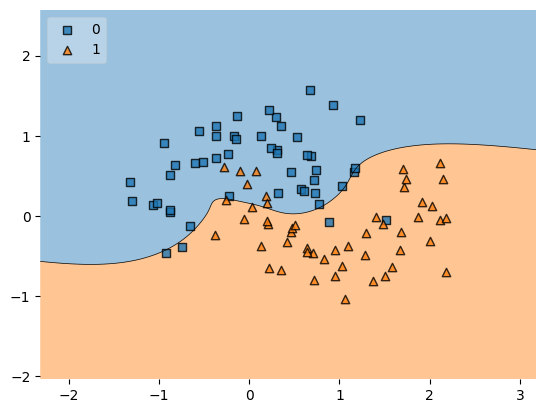

In [85]:
plot_decision_regions(X,Y.astype('int'), clf=model3, legend=2)